# ***Help Functions:***

## Help Functions: random:

In [1]:
#Function that: visualizes the training progress:
import matplotlib.pyplot as plt

def plot_training_history(history):

    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs = range(1, len(acc) + 1)

    plt.figure(figsize=(12, 5))

    # Subplot 1
    plt.subplot(1, 2, 1)
    plt.plot(epochs, acc, 'bo-', label='Training acc')
    plt.plot(epochs, val_acc, 'ro-', label='Validation acc')
    plt.title('Training and validation accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')

    # Add horizontal lines at every axes index
    for i in range(1, len(epochs)+1):
        plt.axvline(x=i, color='gray', linestyle='--', linewidth=0.8)

    plt.legend()

    # Subplot 2
    plt.subplot(1, 2, 2)
    plt.plot(epochs, loss, 'bo-', label='Training loss')
    plt.plot(epochs, val_loss, 'ro-', label='Validation loss')
    plt.title('Training and validation loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')

    # Add horizontal lines at every axes index
    for i in range(1, len(epochs)+1):
        plt.axvline(x=i, color='gray', linestyle='--', linewidth=0.8)

    plt.legend()
    plt.tight_layout()
    plt.show()

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def print_data_distribution(dataset_path, target_name):


    # Load the dataset into a pandas DataFrame
    df = pd.read_csv(dataset_path)

    # Find unique target names and count samples for each
    category_counts = df[target_name].value_counts()

    # Convert the counts to lists for plotting
    classes = category_counts.index.tolist()
    sample_sizes = category_counts.values.tolist()

    print("Mean number of samples: ", np.mean(sample_sizes))

    plt.figure(figsize=(12, 8))
    plt.barh(classes, sample_sizes, color='skyblue')
    plt.xlabel('Number of Samples')
    plt.ylabel('Category')
    plt.title('Distribution of Samples Across Categories')
    plt.tight_layout()

    # Optional: Add the sample sizes next to each bar for clarity
    for index, value in enumerate(sample_sizes):
        plt.text(value, index, str(value))

    plt.show()

In [3]:
# Function that: loads the pre-trained embedding:
from gensim.models import KeyedVectors

def load_pre_trained_embedding(vocab_size, tokenizer):

  word_vectors = KeyedVectors.load_word2vec_format(os.path.join(input_filepath, 'pre-trained-embedding/GoogleNews-vectors-negative300.bin'), binary=True)
  embedding_dim = 300

  # Fill the embedding matrix with Word2Vec vectors
  embedding_matrix = np.zeros((vocab_size, embedding_dim))

  for word, i in tokenizer.word_index.items():
      if word in word_vectors.key_to_index:
          embedding_vector = word_vectors[word]
          embedding_matrix[i] = embedding_vector
  return embedding_matrix

In [4]:
# Function that: gets the correct answers of a dataset:
import pandas as pd

def get_correct_predictions(filepath,  main_classes_encoding, sub_classes_encoding):

    # open the dataset:
    test_df = pd.read_csv(os.path.join(input_filepath, filepath))
    
    # extract the labels:
    actual_labels = []
    
    for index, row in test_df.iterrows():
        
        # Extract the main-class: labels
        main_class_label = row['category_level_1']
        main_class_index = main_classes_encoding.loc[main_classes_encoding['category_level_1'] == main_class_label].index[0]

        
        # Extract the sub-class: labels
        name = main_classes_encoding.loc[main_class_index, 'category_level_1']
        sub_class_encoding = sub_classes_encoding[name]
        
        sub_class_label = row['category_level_2']
        sub_class_index = sub_class_encoding.loc[sub_class_encoding['category_level_2'] == sub_class_label].index[0]

        # Append the tuple of actual labels to the list
        actual_labels.append((main_class_index, sub_class_index))
        
    return actual_labels

## Help Functions for: Data Pre-proccesing:

In [5]:
#Prepare data (split):
import pandas as pd

def load_dataset(class_path):
    
    df = pd.read_csv(os.path.join(input_filepath, class_path))
    df['information'] = df['title'] + ' ' + df['id'] + ' ' + df['source'] + ' ' + df['content']
    
    X = df['information']
    y1 = df['category_level_1']
    y2 = df['category_level_2']
    return X, y1, y2, df

In [6]:
#Function that: removes stopwords:
import nltk
#nltk.download('stopwords')
#nltk.download('punkt')
#nltk.download('wordnet')

def remove_stopwords(text):
    if not isinstance(text, str):
        return ''

    stop_words = set(nltk.corpus.stopwords.words('english'))
    word_tokens = nltk.tokenize.word_tokenize(text)
    filtered_text = [word for word in word_tokens if word.lower() not in stop_words]
    return ' '.join(filtered_text)

In [7]:
from keras.preprocessing.sequence import pad_sequences
from keras.preprocessing.text import Tokenizer
import numpy as np

#Function that: pre-procceses the input data:
def pre_process_inputs(text, precent_wanted):

    #Remove the stopwords:
    filtered_text = text.apply(remove_stopwords)

    #Transform to: sequences of integers:
    tokenizer = Tokenizer()
    tokenizer.fit_on_texts(filtered_text)
    text_sequences = tokenizer.texts_to_sequences(filtered_text)

    # Find the padding length:
    sequence_lengths = [len(seq) for seq in text_sequences]
    padding_length_percentile = np.percentile(sequence_lengths, precent_wanted)
    padding_length = int(np.ceil(padding_length_percentile))

    #Transform to: padded sequences of integers:
    text_sequences_padded = pad_sequences(text_sequences, maxlen=padding_length, padding='post', truncating='post')
    print("Padding length:", padding_length)

    return text_sequences_padded, padding_length, tokenizer

2024-03-03 18:44:18.439002: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-03 18:44:18.439098: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-03 18:44:18.736721: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [8]:
from keras.preprocessing.sequence import pad_sequences
from keras.preprocessing.text import Tokenizer
import numpy as np

#Function that: pre-procceses the input data:
def pre_process_inputs_fixed(text, fixed_length, tokenizer):

    #Remove the stopwords:
    filtered_text = text.apply(remove_stopwords)

    #Transform to: sequences of integers:
    text_sequences = tokenizer.texts_to_sequences(filtered_text)

    #Transform to: padded sequences of integers:
    text_sequences_padded = pad_sequences(text_sequences, maxlen=fixed_length, padding='post', truncating='post')
    print("Padding length:", fixed_length)

    return text_sequences_padded

In [9]:
#Function that: encodes the outputs/targets:
from sklearn.preprocessing import LabelEncoder
from keras.utils import to_categorical

def encode_targets(y, num_classes, classes_encoding, level):

  # Create a dictionary to map class names to indices
  if (level == 1):
      class_to_index = dict(zip(classes_encoding['category_level_1'], classes_encoding.index))
  else:
      class_to_index = dict(zip(classes_encoding['category_level_2'], classes_encoding.index))

  # Map each y value to its corresponding index
  y_indices = np.array([class_to_index[class_name] for class_name in y])

  # Convert indices to one-hot encoded format
  y_one_hot = to_categorical(y_indices, num_classes)

  return  y_one_hot

## Functions about Neural Networks:

In [19]:
#Build the neural network (LSTM):
import tensorflow
from keras import layers, models
from keras.models import Sequential
from keras.layers import Embedding, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, SpatialDropout1D, Bidirectional, LSTM, GlobalMaxPool1D

def build_1d_lstm(padding_length, vocab_size, output_dimension, num_layers, num_outputs, num_lstm_units, num_dense, pre_trained_embedding, tokenizer, learning_rate):

  print("Input size:", padding_length)
  print("Output size:", num_outputs)

  #Initialize model:
  model = Sequential()

  # Embedding layer
  if (pre_trained_embedding == True):
      embedding_matrix = load_pre_trained_embedding(vocab_size, tokenizer)
      model.add(Embedding(input_dim=vocab_size, output_dim=300, weights=[embedding_matrix], input_length=padding_length, trainable=True))
  else:
      model.add(Embedding(input_dim=vocab_size, output_dim=output_dimension, input_length=padding_length))

  model.add(SpatialDropout1D(0.2))

  # LSTM layer:
  model.add(Bidirectional(LSTM(num_lstm_units, return_sequences=False)))
  #model.add(Bidirectional(LSTM(num_lstm_units, return_sequences=False, dropout=0.2, recurrent_dropout=0.2)))

  # Fully connected layers
  #model.add(Dense(units=num_dense, activation='linear'))
  #model.add(Dropout(0.4))

  # Output layer (adjust based on your task)
  model.add(Dense(units=num_outputs, activation='softmax'))
  model.summary()

  #Compile the neural network:
  model.compile(optimizer=tensorflow.keras.optimizers.Adam(learning_rate=learning_rate), loss='categorical_crossentropy', metrics=['accuracy'])
  return model

In [20]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight

# Function that: receives a dataset and returns a trained model:
def build_trained_lstm_model(filepath, percentage_wanted, num_outputs, output_dimension, num_layers, num_lstm_units, num_dense, val_percent, pre_trained_embedding, level, classes_encoding, learning_rate):

    # Load the data: main Neural Network:
    X, y1, y2, df = load_dataset(filepath)

    #Pre-process inputs:
    X_sequences_padded, padding_length, tokenizer = pre_process_inputs(X, percentage_wanted)
    vocab_size = len(tokenizer.word_index) + 1
    print("vocab size: ", vocab_size)

    #Transform targets to one-hot labels:
    if (level == 1):
        y_one_hot = encode_targets(y1, num_outputs, classes_encoding, level)
    else:
        y_one_hot = encode_targets(y2, num_outputs, classes_encoding, level)

    #Split the data:
    X_sequences_padded_train, X_sequences_padded_val, y_one_hot_train, y_one_hot_val = train_test_split(X_sequences_padded,
                                                                                                        y_one_hot,
                                                                                                        test_size=val_percent,
                                                                                                        shuffle = True,
                                                                                                        random_state=42)

    print("Length of X:", len(X_sequences_padded), ", Length of X_train:", len(X_sequences_padded_train), ", Length of X_val:", len(X_sequences_padded_val))

    #Build the neural network (LSTM):
    new_model = build_1d_lstm(padding_length=padding_length,
                              vocab_size=vocab_size,
                              output_dimension=output_dimension,
                              num_layers=num_layers,
                              num_lstm_units=num_lstm_units,
                              num_dense=num_dense,
                              pre_trained_embedding=pre_trained_embedding,
                              num_outputs=num_outputs,
                              tokenizer=tokenizer,
                              learning_rate=learning_rate)

    #Train the model:
    batch_size = int(round(len(X_sequences_padded_train) / 25))
    #batch_size = 5
    print("Samples: ", len(X_sequences_padded_train), ", batch size: ", batch_size)
    early_stopping = EarlyStopping(monitor='val_accuracy', patience=7, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_accuracy', factor=0.2, patience=3, min_lr=0.001)

    
    # Class weights:
    if (level == 1):
      category_to_index = {category: index for index, category in enumerate(classes_encoding['category_level_1'])}
      y_train_encoded = np.array([category_to_index[value] for value in y1])

      classes = classes_encoding['category_level_1'].values
      class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_encoded), y=y_train_encoded)
      class_weights_dict = {i: weight for i, weight in enumerate(class_weights)}
    else:
      class_weights_dict = None
    
    
    
    # Train the model
    history = new_model.fit(X_sequences_padded_train,
                            y_one_hot_train,
                            epochs=25,
                            batch_size=batch_size,
                            class_weight=class_weights_dict,
                            validation_data=(X_sequences_padded_val, y_one_hot_val),
                            callbacks=[early_stopping, reduce_lr])

    return new_model, history, padding_length, tokenizer

In [12]:
# Function that: evaluates the Neural-Network: 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, accuracy_score


def evaluate_model(model, input_length, tokenizer, classes_encoding, filepath, level, subclasses_num):

    # Load the test dataset:
    X_test, y1_test, y2_test, test_df = load_dataset(filepath)

    # Make the predictions:
    X_sequences_padded = pre_process_inputs_fixed(text=X_test, fixed_length=input_length, tokenizer=tokenizer)
    y_pred = model.predict(X_sequences_padded)

    # Get the legit answers:
    if (level == 1):
        y_test = encode_targets(y=y1_test, num_classes=subclasses_num, classes_encoding=classes_encoding, level=1)
    else:
        y_test = encode_targets(y=y2_test, num_classes=subclasses_num, classes_encoding=classes_encoding, level=2)

    # Turn to ints:
    y_test_labels = y_test.argmax(axis=1)
    y_pred_labels = y_pred.argmax(axis=1)

    # Calculate metrics
    accuracy = accuracy_score(y_test_labels, y_pred_labels)
    precision = precision_score(y_test_labels, y_pred_labels, average='macro')
    recall = recall_score(y_test_labels, y_pred_labels, average='macro')
    f1 = f1_score(y_test_labels, y_pred_labels, average='macro')
    report = classification_report(y_test_labels, y_pred_labels, output_dict=False)

    # Print the evaluation metrics
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")
    print(report)

    # Confusion Matrix
    conf_matrix = confusion_matrix(y_test_labels, y_pred_labels)
    print("Confusion Matrix:\n", conf_matrix)

# ***Main Program - Initialization:***

## Set the base-filepaths:

In [13]:
import os
input_filepath = '/kaggle/input'
output_filepath = '/kaggle/working'

## Encoding of Main-Classes/Sub-Classes:

In [14]:
# Encoding: the Main-Classes:
import pandas as pd

df_dataset = pd.read_csv(os.path.join(input_filepath, 'original-dataset/news-classification.csv'))
main_classes_encoding = df_dataset.groupby('category_level_1')['category_level_2'].nunique().reset_index(name='NumOfSubClasses')
print(main_classes_encoding)

                             category_level_1  NumOfSubClasses
0      arts, culture, entertainment and media                3
1                     conflict, war and peace                8
2                      crime, law and justice                5
3   disaster, accident and emergency incident                5
4               economy, business and finance                4
5                                   education                6
6                                 environment                6
7                                      health                7
8                              human interest                6
9                                      labour                7
10                      lifestyle and leisure                3
11                                   politics                9
12                        religion and belief                8
13                     science and technology                8
14                                    society          

In [15]:
# Encoding: the Sub-Classes:
grouped = df_dataset.groupby('category_level_1')
sub_classes_encoding = {}

for main_class, group in grouped:

    # Extract unique sub-classes for the current main class
    unique_sub_classes = group['category_level_2'].unique()

    # Create a DataFrame for the current main class
    df_sub_classes = pd.DataFrame(unique_sub_classes, columns=['category_level_2'])

    # Store the DataFrame in the dictionary
    sub_classes_encoding[main_class] = df_sub_classes

# Use the array of dataframes:
name = main_classes_encoding.loc[15, 'category_level_1']
print(name)
print(sub_classes_encoding[name])

sport
               category_level_2
0             drug use in sport
1                  bodybuilding
2                   sport event
3                      transfer
4                   sport venue
5        competition discipline
6  disciplinary action in sport
7            sport organisation
8                sport industry


# ***Main Program - Main Classifier:***

## Train the Main Classifier:

In [16]:
import time
start_time = time.time()

# Train the network:
main_network, main_history, main_input_length, main_tokenizer = build_trained_lstm_model(filepath='main-train-dataset/train-news-classification.csv',
                                                                                            percentage_wanted=90,
                                                                                            num_outputs=17,
                                                                                            output_dimension=300,
                                                                                            num_layers=1,
                                                                                            num_lstm_units=150,
                                                                                            num_dense=0,
                                                                                            val_percent=0.08395,
                                                                                            level=1,
                                                                                            pre_trained_embedding = True,
                                                                                            classes_encoding=main_classes_encoding,
                                                                                            learning_rate=0.001
                                                                                            )
end_time = time.time()
total_time = end_time - start_time
print(f"Training took {total_time} seconds")

main_max_val_accuracy = max(main_history.history['val_accuracy'])
main_model_info = ({
        "model": main_network,
        "history": main_history,
        "padding_length": main_input_length,
        "tokenizer": main_tokenizer,
        "val_accuracy": main_max_val_accuracy
    })

Padding length: 761
vocab size:  101394
Length of X: 9825 , Length of X_train: 9000 , Length of X_val: 825
Input size: 761
Output size: 17
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 761, 300)          30418200  
                                                                 
 spatial_dropout1d (Spatial  (None, 761, 300)          0         
 Dropout1D)                                                      
                                                                 
 bidirectional (Bidirection  (None, 300)               541200    
 al)                                                             
                                                                 
 dense (Dense)               (None, 17)                5117      
                                                                 
Total params: 30964517 (118.12 MB)
Trainable para

I0000 00:00:1709491720.446397     118 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


25/25 [==============================] - 78s 3s/step - loss: 2.4634 - accuracy: 0.2833 - val_loss: 2.0083 - val_accuracy: 0.4242 - lr: 0.0010
Epoch 2/25
25/25 [==============================] - 71s 3s/step - loss: 1.5948 - accuracy: 0.5294 - val_loss: 1.3598 - val_accuracy: 0.6109 - lr: 0.0010
Epoch 3/25
25/25 [==============================] - 71s 3s/step - loss: 1.0432 - accuracy: 0.6727 - val_loss: 0.9889 - val_accuracy: 0.7079 - lr: 0.0010
Epoch 4/25
25/25 [==============================] - 71s 3s/step - loss: 0.6709 - accuracy: 0.7958 - val_loss: 0.7670 - val_accuracy: 0.7867 - lr: 0.0010
Epoch 5/25
25/25 [==============================] - 70s 3s/step - loss: 0.4531 - accuracy: 0.8610 - val_loss: 0.7046 - val_accuracy: 0.7939 - lr: 0.0010
Epoch 6/25
25/25 [==============================] - 71s 3s/step - loss: 0.3332 - accuracy: 0.8990 - val_loss: 0.6600 - val_accuracy: 0.8061 - lr: 0.0010
Epoch 7/25
25/25 [==============================] - 71s 3s/step - loss: 0.2428 - accuracy: 0.

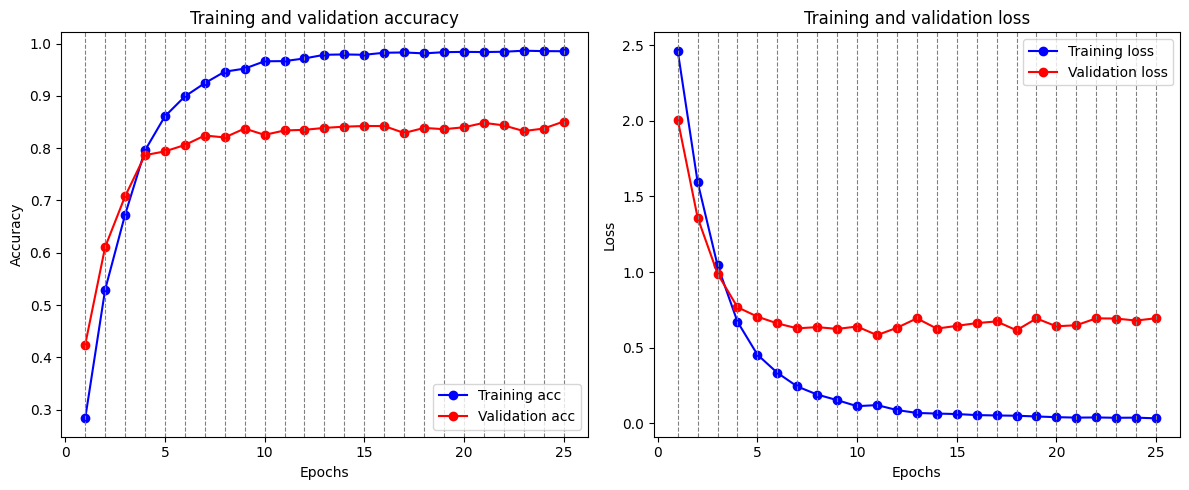

In [17]:
plot_training_history(main_history)

## Save the trained Main Classifier (in file):

In [20]:
# Save the main model:
import os
import pickle
from keras.models import load_model

# Folder to save the model:
save_dir = os.path.join(output_filepath, 'saved_models')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    
# Save the Keras model
model_path = os.path.join(save_dir, f"main_model.h5")
main_model_info['model'].save(model_path)

# Prepare components to save without the model
components_to_save = {key: value for key, value in main_model_info.items() if key != 'model'}

# Save additional components with pickle
info_path = os.path.join(save_dir, f"main_model.pickle")
with open(info_path, 'wb') as handle:
    pickle.dump(components_to_save, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
print(f"Saved Main Model and its info in {save_dir}")

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Saved Main Model and its info in /kaggle/working/saved_models


## Load the Main Classifier:

In [28]:
import pickle
from tensorflow.keras.models import load_model

# Load the model:
main_network = load_model(os.path.join(input_filepath, 'trained-main-model-2/main_model.h5'))

# Load the info:
with open(os.path.join(input_filepath, 'trained-main-model-2/main_model.pickle'), 'rb') as handle:
    info = pickle.load(handle)
main_tokenizer = info['tokenizer']
main_input_length = info['padding_length']
print(main_input_length)

761


## Evaluate the Main Classifier:

In [33]:
evaluate_model(model=main_network,
               input_length=main_input_length,
               tokenizer=main_tokenizer,
               classes_encoding=main_classes_encoding,
               filepath='main-test-dataset/test-news-classification.csv',
               level=1,
               subclasses_num=17
              )

Padding length: 761
35/35 [==============================] - 14s 404ms/step
Accuracy: 0.8186813186813187
Precision: 0.8222664055964768
Recall: 0.8198622180348313
F1 Score: 0.8192520033133678
              precision    recall  f1-score   support

           0       0.84      0.87      0.85        30
           1       0.89      0.91      0.90        80
           2       0.81      0.70      0.75        50
           3       0.66      0.62      0.64        50
           4       0.89      0.78      0.83        40
           5       0.75      0.85      0.80        61
           6       0.73      0.90      0.81        60
           7       0.91      0.84      0.87        70
           8       0.79      0.88      0.83        60
           9       0.89      0.91      0.90        70
          10       0.87      0.87      0.87        30
          11       0.73      0.78      0.75        90
          12       0.78      0.76      0.77        80
          13       0.78      0.70      0.74        8

# ***Main Program: Sub-Classifiers:***

## Train the Sub-Nets (at once):

In [23]:
# Parameters for each of the 17 models: 
import time
num_lstm_units_list = [100, 100, 100, 100, 100, 100, 50, 150, 100,
                       100, 100, 100, 100, 150, 100, 100, 100]
pre_trained_embedding_list = [True, True, True, True, True, True, True, True, True,
                               True, True, True, True, True, True, True, True]

# List to store models and their information
trained_models_info = []

# Loop to create, train each model, and store its information
start_time = time.time()
for i, (num_lstm_units, pre_trained_embedding) in enumerate(zip(num_lstm_units_list, pre_trained_embedding_list)):
    
    print("\n================================")
    
    # Get the name of the main-class:
    main_class_name = main_classes_encoding.loc[i, 'category_level_1']
    main_class_name = main_class_name.replace(",", "")
    print(main_class_name)
    
    # Get the path of the main-class dataset:
    sub_dataset_path = 'sub-train-dataset/train_' + main_class_name + '.csv'

    # Get the number of the main-class' sub-classes:
    subclasses_num = main_classes_encoding.loc[i, 'NumOfSubClasses']

    # Get the encoding of the main-class and its sub-classes:
    name = main_classes_encoding.loc[i, 'category_level_1']
    sub_class_encoding = sub_classes_encoding[name]
    print(sub_class_encoding)
    
    # Train the classifier:
    new_model, history, padding_length, tokenizer = build_trained_lstm_model(
                                                        filepath=sub_dataset_path, 
                                                        percentage_wanted=90, 
                                                        num_outputs=subclasses_num, 
                                                        output_dimension=300, 
                                                        num_layers=1, 
                                                        num_lstm_units=num_lstm_units, 
                                                        val_percent=0.1, 
                                                        pre_trained_embedding=pre_trained_embedding, 
                                                        level=2, 
                                                        classes_encoding=sub_class_encoding,
                                                        learning_rate=0.001,
                                                        num_dense=0
                                                    )
    # Save the accuracy of the trained model:
    max_val_accuracy = max(history.history['val_accuracy'])
    print("Best val: ", max_val_accuracy)

    # Append the model and its information to the list:
    trained_models_info.append({
        "model": new_model,
        "padding_length": padding_length,
        "tokenizer": tokenizer,
        "val_accuracy": max_val_accuracy
    })
    
end_time = time.time()
total_time = end_time - start_time
print(f"Training took {total_time} seconds")

# Calculate the average of the best validation accuracies
total_accuracy = sum(model_info['val_accuracy'] for model_info in trained_models_info)
average_accuracy = total_accuracy / len(trained_models_info)

# Print the average accuracy
print(f"Average Best Validation Accuracy: {average_accuracy:.4f}")


arts culture entertainment and media
         category_level_2
0  arts and entertainment
1              mass media
2                 culture
Padding length: 717
vocab size:  17727
Length of X: 270 , Length of X_train: 243 , Length of X_val: 27
Input size: 717
Output size: 3
Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_1 (Embedding)     (None, 717, 300)          5318100   
                                                                 
 spatial_dropout1d_1 (Spati  (None, 717, 300)          0         
 alDropout1D)                                                    
                                                                 
 bidirectional_1 (Bidirecti  (None, 200)               320800    
 onal)                                                           
                                                                 
 dense_1 (Dense)             (None, 3)    

## Save the Sub-Classifiers (at once):

In [20]:
import os
import pickle
from keras.models import load_model

# Create the folder:
save_dir = "/kaggle/working/saved_models"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Save information in files:
for i, model_info in enumerate(trained_models_info):
    
    # Save the Keras model
    model_path = os.path.join(save_dir, f"model_{i+1}.h5")
    model_info['model'].save(model_path)
    
    # Prepare components to save without the model
    components_to_save = {key: value for key, value in model_info.items() if key != 'model'}
    
    # Save additional components with pickle
    info_path = os.path.join(save_dir, f"model_{i+1}.pickle")
    with open(info_path, 'wb') as handle:
        pickle.dump(components_to_save, handle, protocol=pickle.HIGHEST_PROTOCOL)
    
    print(f"Saved Model {i+1} and its info in {save_dir}")

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Saved Model 1 and its info in /kaggle/working/saved_models
Saved Model 2 and its info in /kaggle/working/saved_models
Saved Model 3 and its info in /kaggle/working/saved_models
Saved Model 4 and its info in /kaggle/working/saved_models
Saved Model 5 and its info in /kaggle/working/saved_models
Saved Model 6 and its info in /kaggle/working/saved_models
Saved Model 7 and its info in /kaggle/working/saved_models
Saved Model 8 and its info in /kaggle/working/saved_models
Saved Model 9 and its info in /kaggle/working/saved_models
Saved Model 10 and its info in /kaggle/working/saved_models
Saved Model 11 and its info in /kaggle/working/saved_models
Saved Model 12 and its info in /kaggle/working/saved_models
Saved Model 13 and its info in /kaggle/working/saved_models
Saved Model 14 and its info in /kaggle/working/saved_models
Saved Model 15 and its info in /kaggle/working/saved_models
Saved Model 16 and its info in /kaggle/working/saved_models
Saved Model 17 and its info in /kaggle/working/sa

## Load the Sub-Classifiers (at once):

In [36]:
import pickle
import os
from tensorflow.keras.models import load_model

num_sub_classifiers = 17
sub_classifiers_info = []

# Load every sub-classifier:
for i in range(1, num_sub_classifiers + 1):
    
    # Filepaths:
    pickle_file_path = os.path.join(input_filepath, f'trained-sub-models/model_{i}.pickle')
    model_file_path = os.path.join(input_filepath, f'trained-sub-models/model_{i}.h5')
    
    # Initialize a dictionary to hold the loaded data and model
    classifier_info = {}
    
    # Get information of sub-classifier:
    with open(pickle_file_path, 'rb') as file:
        info = pickle.load(file)
    classifier_info['tokenizer'] = info['tokenizer']
    classifier_info['input_length'] = info['padding_length']
                           
    # Get the model:
    classifier_info['model'] = load_model(model_file_path)
    
    # Store the sub-classifier:
    sub_classifiers_info.append(classifier_info)

## Evaluate the Sub-Classifiers (separately):

In [32]:
# Get the name of the main-class:
i = 11 # user controls index of sub-classifier
main_class_name = main_classes_encoding.loc[i, 'category_level_1']
main_class_name = main_class_name.replace(",", "")
print(main_class_name)
    
# Get the path of the main-class dataset:
filepath = 'sub-test-dataset/test_' + main_class_name + '.csv'

# Get the number of the main-class' sub-classes:
subclasses_num = main_classes_encoding.loc[i, 'NumOfSubClasses']

# Get the encoding of the main-class and its sub-classes:
name = main_classes_encoding.loc[i, 'category_level_1']
sub_class_encoding = sub_classes_encoding[name]
print(sub_class_encoding)

evaluate_model(model=sub_classifiers_info[i]['model'],
               input_length=sub_classifiers_info[i]['input_length'],
               tokenizer=sub_classifiers_info[i]['tokenizer'],
               classes_encoding=sub_class_encoding,
               filepath=filepath,
               level=2,
               subclasses_num=subclasses_num)

politics
                category_level_2
0                       election
1               political crisis
2              political dissent
3             fundamental rights
4                     government
5        international relations
6              government policy
7  non-governmental organisation
8              political process
Padding length: 784
3/3 [==============================] - 0s 45ms/step
Accuracy: 0.6888888888888889
Precision: 0.6873182373182373
Recall: 0.7645573380867497
F1 Score: 0.6960241145977225
              precision    recall  f1-score   support

           0       0.90      0.75      0.82        12
           1       0.75      1.00      0.86         9
           2       0.60      0.18      0.27        17
           3       0.54      0.70      0.61        10
           4       0.64      0.90      0.75        10
           5       0.80      1.00      0.89         8
           6       1.00      0.90      0.95        10
           7       0.50      1.00      0.

## Save the Sub-Classifiers (separately):

In [44]:
# Save the sub-model in file:
import os
import pickle
from keras.models import load_model

# Create the folder:
save_dir = "/kaggle/working/saved_models"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)
    
model_info =({
        "model": sub_network,
        "padding_length": sub_padding_length,
        "tokenizer": sub_tokenizer,
        "val_accuracy": best
    })
    
# Save the Keras model
i = 14 # user controls index of sub-classifier
model_path = os.path.join(save_dir, f"model_{i}.h5")
model_info['model'].save(model_path)

# Prepare components to save without the model
components_to_save = {key: value for key, value in model_info.items() if key != 'model'}

# Save additional components with pickle
info_path = os.path.join(save_dir, f"model_{i}.pickle")
with open(info_path, 'wb') as handle:
    pickle.dump(components_to_save, handle, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved Model {i} and its info in {save_dir}")

/opt/conda/lib/python3.10/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Saved Model 14 and its info in /kaggle/working/saved_models


## Train the Sub-Classifiers (separately):

In [61]:
# Training: just the 1t Sub-Net:
i = 14 # user controls index of sub-classifier
main_class_name = main_classes_encoding.loc[i, 'category_level_1']
main_class_name = main_class_name.replace(",", "")

sub_dataset_path = 'sub-train-dataset/train_' + main_class_name + '.csv'

subclasses_num = main_classes_encoding.loc[i, 'NumOfSubClasses']

# Use the array of dataframes:
name = main_classes_encoding.loc[i, 'category_level_1']
sub_class_encoding = sub_classes_encoding[name]
print(name)
print(sub_class_encoding)

sub_network, sub_history, sub_padding_length, sub_tokenizer = build_trained_lstm_model(filepath=sub_dataset_path,
                                                                                        percentage_wanted=90,
                                                                                        num_outputs=subclasses_num,
                                                                                        output_dimension=300,
                                                                                        num_layers=1,
                                                                                        num_lstm_units=100,
                                                                                        val_percent=0.1,
                                                                                        pre_trained_embedding = True,
                                                                                        level=2,
                                                                                        classes_encoding=sub_class_encoding
                                                                                        )

best = max(sub_history.history['val_accuracy'])
print(f"Best validation accuracy for {main_class_name}: {best}")

arts, culture, entertainment and media
         category_level_2
0  arts and entertainment
1              mass media
2                 culture
Padding length: 717
vocab size:  17727
Length of X: 270 , Length of X_train: 243 , Length of X_val: 27
Input size: 717
Output size: 3
Model: "sequential_7"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_7 (Embedding)     (None, 717, 300)          5318100   
                                                                 
 spatial_dropout1d_7 (Spati  (None, 717, 300)          0         
 alDropout1D)                                                    
                                                                 
 bidirectional_7 (Bidirecti  (None, 200)               320800    
 onal)                                                           
                                                                 
 dense_7 (Dense)             (None, 3)   

# ***Connect Levels - Test:***

## Test First layer:

In [29]:
import time

# Load the test dataset:
X_test, y1_test, y2_test, test_df = load_dataset('main-test-dataset/test-news-classification.csv')

# Make the predictions:
X_sequences_padded = pre_process_inputs_fixed(text=X_test, fixed_length=main_input_length, tokenizer=main_tokenizer)
y_main_pred = main_network.predict(X_sequences_padded)

# Turn to ints:
y_main_pred_labels = y_main_pred.argmax(axis=1)

Padding length: 761
35/35 [==============================] - 15s 413ms/step


## Test Second layer:

In [30]:
# Second layer:

final_predictions = []

# Predict the sub-class:
for i in range(len(X_test)):
    
    # Get the input:
    test_instance = X_test.iloc[i:i+1]     
    
    # Get the index of the sub-classifier
    main_class_label = y_main_pred_labels[i]
    
    # Get the sub-classifier and its info:
    sub_classifier = sub_classifiers_info[main_class_label]['model']
    sub_input_length = sub_classifiers_info[main_class_label]['input_length']
    sub_tokenizer = sub_classifiers_info[main_class_label]['tokenizer']
    
    # Predict the sub-class
    X_sequences_padded = pre_process_inputs_fixed(text=test_instance, fixed_length=sub_input_length, tokenizer=sub_tokenizer)
    y_sub_pred = sub_classifier.predict(X_sequences_padded)
    y_sub_pred_label = y_sub_pred.argmax(axis=1)
    
    # Store the final prediction
    final_prediction = (main_class_label, y_sub_pred_label[0])
    final_predictions.append(final_prediction)

Padding length: 845
1/1 [==============================] - 0s 37ms/step
Padding length: 627
1/1 [==============================] - 0s 32ms/step
Padding length: 1177
1/1 [==============================] - 0s 45ms/step
Padding length: 678
1/1 [==============================] - 0s 33ms/step
Padding length: 784
1/1 [==============================] - 0s 35ms/step
Padding length: 696
1/1 [==============================] - 0s 33ms/step
Padding length: 696
1/1 [==============================] - 0s 34ms/step
Padding length: 614
1/1 [==============================] - 0s 31ms/step
Padding length: 1177
1/1 [==============================] - 0s 45ms/step
Padding length: 696
1/1 [==============================] - 0s 33ms/step
Padding length: 1177
1/1 [==============================] - 0s 46ms/step
Padding length: 648
1/1 [==============================] - 0s 32ms/step
Padding length: 686
1/1 [==============================] - 0s 33ms/step
Padding length: 763
1/1 [==============================] - 0s

## Evaluating:

In [26]:
# Get the correct answers:
actual_labels = get_correct_predictions('main-test-dataset/test-news-classification.csv', main_classes_encoding, sub_classes_encoding)
print(actual_labels)

[(5, 4), (3, 2), (13, 3), (14, 9), (11, 8), (15, 0), (15, 8), (13, 2), (13, 5), (15, 7), (3, 4), (2, 2), (2, 2), (1, 6), (14, 5), (9, 6), (13, 6), (5, 4), (6, 5), (9, 3), (12, 1), (8, 1), (8, 1), (15, 6), (16, 0), (12, 7), (5, 0), (10, 0), (2, 0), (16, 1), (6, 5), (16, 3), (7, 0), (7, 3), (4, 3), (13, 3), (14, 5), (8, 4), (7, 0), (13, 2), (8, 4), (7, 5), (15, 7), (15, 1), (5, 5), (14, 10), (8, 1), (1, 2), (1, 5), (0, 1), (9, 5), (15, 4), (11, 2), (5, 1), (13, 4), (14, 8), (14, 2), (2, 1), (5, 0), (9, 3), (14, 7), (11, 3), (12, 2), (14, 7), (1, 0), (5, 0), (6, 2), (6, 3), (11, 0), (12, 1), (3, 2), (11, 8), (11, 5), (2, 4), (11, 4), (12, 7), (0, 0), (13, 2), (5, 3), (0, 1), (15, 2), (5, 3), (7, 4), (2, 0), (16, 2), (6, 4), (7, 1), (1, 6), (3, 4), (13, 3), (9, 4), (12, 5), (14, 4), (11, 8), (14, 5), (1, 6), (15, 1), (2, 3), (15, 8), (11, 8), (14, 9), (13, 6), (14, 1), (7, 0), (15, 7), (13, 0), (1, 4), (7, 6), (7, 0), (3, 3), (7, 0), (14, 7), (16, 0), (13, 0), (9, 1), (11, 4), (15, 4), (8,

In [31]:
# Evalaute: 1st level accuracy:

# Extract the main-class indexes from predictions and answers (the first element of each tuple)
main_class_predictions = [pred[0] for pred in final_predictions]
main_class_answers = [ans[0] for ans in actual_labels]

# Calculate the number of correct predictions
correct_predictions = sum(pred == ans for pred, ans in zip(main_class_predictions, main_class_answers))

# Advanced metrics:
report = classification_report(main_class_answers, main_class_predictions, output_dict=False)
print(report)

# Calculate the accuracy
total_predictions = len(actual_labels)
first_level_accuracy = correct_predictions / total_predictions

print(f'Average accuracy: {first_level_accuracy:.2f}')

              precision    recall  f1-score   support

           0       0.84      0.87      0.85        30
           1       0.89      0.91      0.90        80
           2       0.81      0.70      0.75        50
           3       0.66      0.62      0.64        50
           4       0.89      0.78      0.83        40
           5       0.75      0.85      0.80        61
           6       0.73      0.90      0.81        60
           7       0.91      0.84      0.87        70
           8       0.79      0.88      0.83        60
           9       0.89      0.91      0.90        70
          10       0.87      0.87      0.87        30
          11       0.73      0.78      0.75        90
          12       0.78      0.76      0.77        80
          13       0.78      0.70      0.74        80
          14       0.84      0.75      0.79       110
          15       0.90      0.93      0.92        91
          16       0.92      0.88      0.90        40

    accuracy              

In [28]:
# Evalaute: 2nd level accuracy:

# Calculate the number of correct predictions (both main and sub-class indexes must match)
correct_predictions = sum(pred == ans for pred, ans in zip(final_predictions, actual_labels))

# Calculate the accuracy
total_predictions = len(actual_labels)
accuracy = correct_predictions / total_predictions

print(f'Second-level Accuracy: {accuracy:.2f}')

Second-level Accuracy: 0.65
